<a href="https://colab.research.google.com/github/mohammadhadiGhadam/Machine_Learning_2024/blob/main/Miniproject2_machin_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1

**Part 3**

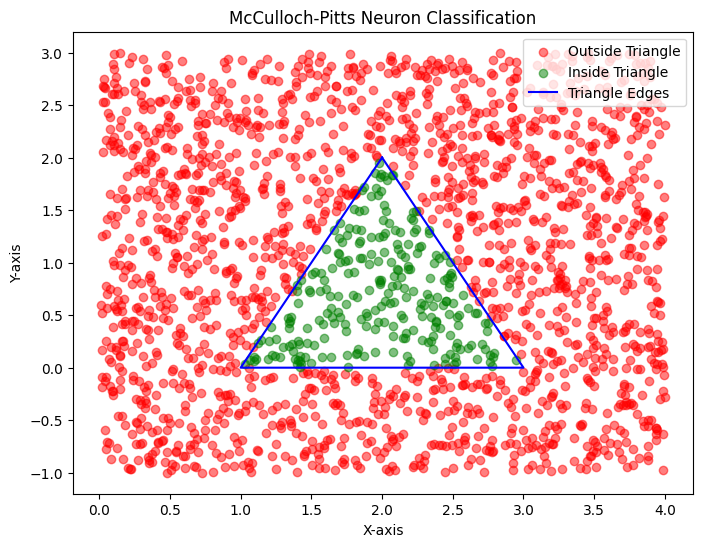

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define the triangular region using linear inequalities
# Triangle vertices: A(2, 2), B(3, 0), C(1, 0)
def is_above_line(p, p1, p2):
    """Check if point p is above the line formed by p1 and p2."""
    return (p2[0] - p1[0]) * (p[1] - p1[1]) - (p2[1] - p1[1]) * (p[0] - p1[0]) >= 0

def is_inside_triangle(point):
    A = np.array([2, 2])
    B = np.array([3, 0])
    C = np.array([1, 0])

    # Check if the point is on the correct side of all three edges
    return (
        is_above_line(point, B, A) and  # Above line BA
        is_above_line(point, C, B) and  # Above line CB
        is_above_line(point, A, C)      # Above line AC
    )

# Step 2: Generate random points
np.random.seed(42)
num_points = 2000
x = np.random.uniform(0, 4, num_points)
y = np.random.uniform(-1, 3, num_points)
points = np.column_stack((x, y))

# Step 3: Classify points using McCulloch-Pitts logic
labels = np.array([1 if is_inside_triangle(p) else 0 for p in points])

# Step 4: Visualize the results
plt.figure(figsize=(8, 6))
plt.title("McCulloch-Pitts Neuron Classification")
plt.scatter(x[labels == 0], y[labels == 0], color='red', label='Outside Triangle', alpha=0.5)
plt.scatter(x[labels == 1], y[labels == 1], color='green', label='Inside Triangle', alpha=0.5)

# Add triangle edges
triangle_vertices = np.array([[2, 2], [3, 0], [1, 0], [2, 2]])
plt.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], color='blue', label='Triangle Edges')

plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

## Question 2

importing the data

In [1]:
# Install gdown if it's not already installed
!pip install gdown --quiet

# Use gdown to download the file from Google Drive
import gdown

# Define the file ID from the Google Drive link
file_id = "16oh_W5Y6L_X5CzSLVJEaCpilB4nVjLnx"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file
output = "teleCust1000t.csv"  # Specify the desired output filename
gdown.download(url, output, quiet=False)

# Import pandas and read the dataset
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv(output)

Downloading...
From: https://drive.google.com/uc?id=16oh_W5Y6L_X5CzSLVJEaCpilB4nVjLnx
To: /content/teleCust1000t.csv
100%|██████████| 37.0k/37.0k [00:00<00:00, 46.3MB/s]


Heatmap

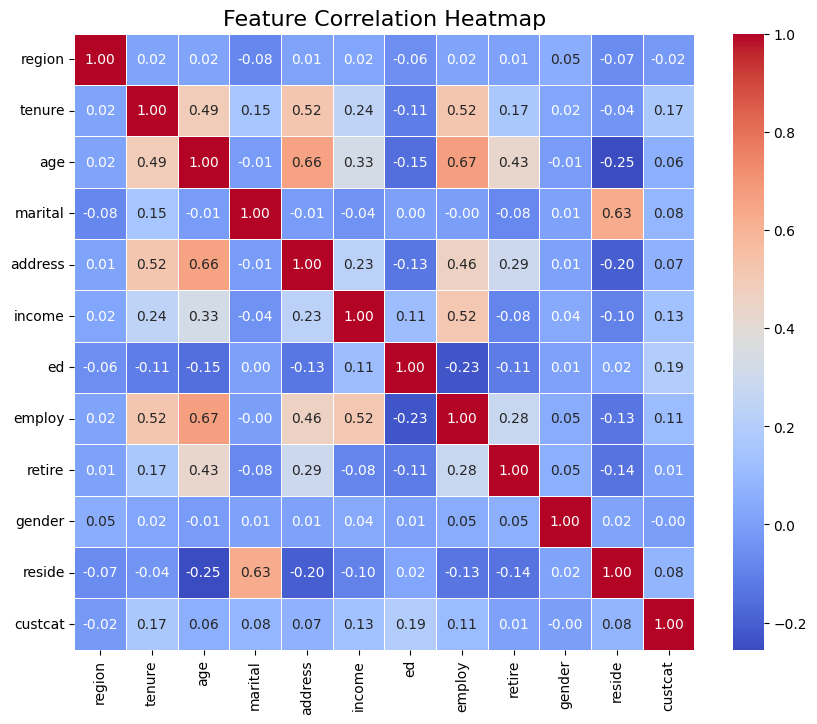

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (ensure the file path is correct or use the previous dataset loaded in Colab)
df = pd.read_csv("teleCust1000t.csv")

# Compute the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add a title to the heatmap
plt.title("Feature Correlation Heatmap", fontsize=16)

# Show the plot
plt.show()

Histogram

Top two features most correlated with 'custcat': ['ed', 'tenure']


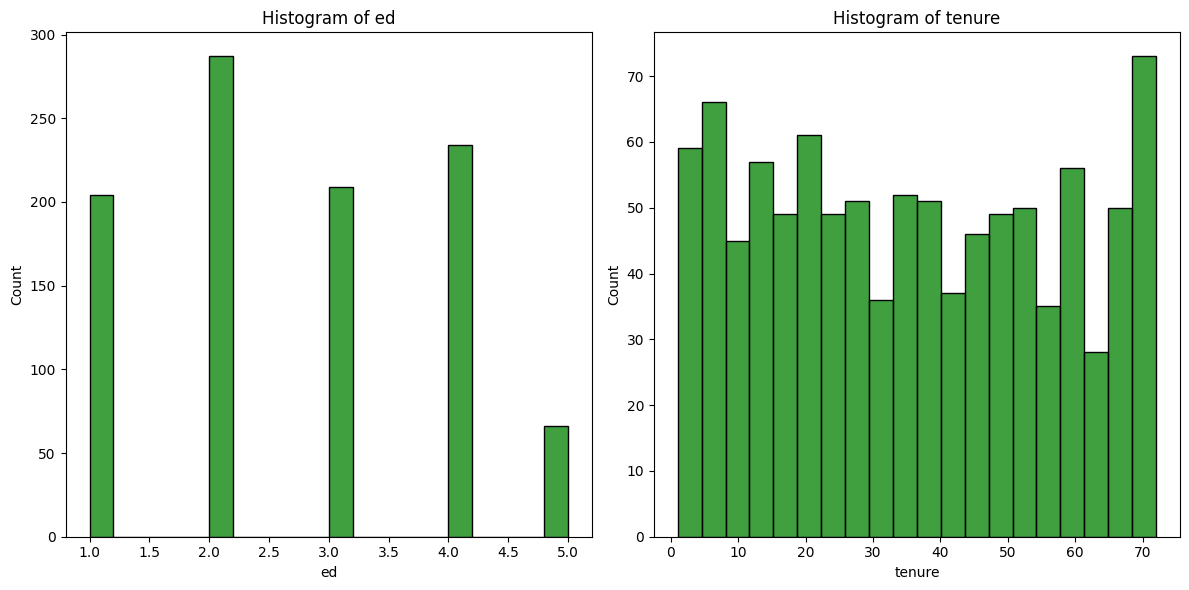

In [3]:
# Select the target feature
target_feature = "custcat"

# Find correlations with the target feature 'custcat'
correlations = correlation_matrix[target_feature].drop(target_feature)

# Identify the two most correlated features
top_two_features = correlations.abs().nlargest(2).index.tolist()
print(f"Top two features most correlated with '{target_feature}': {top_two_features}")

# Plot histograms for the two features
plt.figure(figsize=(12, 6))

for i, feature in enumerate(top_two_features):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[feature], kde=False, bins=20, color='green')
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


normalize and separate the dataset

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Ensure the target column values are integers and zero-indexed
df['custcat'] = df['custcat'] - 1
df['custcat'] = df['custcat'].astype(int)

# Check the unique values in the target column
print(df['custcat'].unique())

# Separate the features (X) and target (y)
X = df.drop(columns=["custcat"])
y = df["custcat"]

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets (75% train, 25% test)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Split the temporary set into validation and test sets (50% validation, 50% test of the 25%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print the shapes of the datasets
print(f"Training set: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set: X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Test set: X_test: {X_test.shape}, y_test: {y_test.shape}")

[0 3 2 1]
Training set: X_train: (750, 11), y_train: (750,)
Validation set: X_val: (125, 11), y_val: (125,)
Test set: X_test: (125, 11), y_test: (125,)


Makeing the MLP network

In [10]:
!pip install tensorflow --quiet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Define input shape (number of features)
input_shape = X_train.shape[1]

# Ensure the target labels are integers
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Function to build and compile a model
def create_mlp_model(hidden_layers, input_dim, output_dim):
    model = Sequential()

    # Add an input layer
    model.add(Input(shape=(input_dim,)))

    # Add hidden layers dynamically based on input
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))

    # Add output layer
    model.add(Dense(output_dim, activation='sigmoid'))  # Output layer for classification

    # Compile the model with SGD optimizer
    optimizer = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Create MLP with 8 NEURON
mlp_8 = create_mlp_model([8], input_dim=input_shape, output_dim=len(y_train.unique()))

# Create MLP with 64 NEURON
mlp_64 = create_mlp_model([64], input_dim=input_shape, output_dim=len(y_train.unique()))

# Train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    #print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")
    return history

# Train the model with one hidden layer
history_one_hidden = train_and_evaluate_model(mlp_8, X_train, y_train, X_val, y_val)

# Train the model with two hidden layers
history_two_hidden = train_and_evaluate_model(mlp_64, X_train, y_train, X_val, y_val)

# Evaluate models on the test set
print("\nEvaluating MLP with 8 neurons on test data:")
test_loss_one, test_acc_one = mlp_8.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_one}, Test Accuracy: {test_acc_one}")

print("\nEvaluating MLP with 64 neurons on test data:")
test_loss_two, test_acc_two = mlp_64.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_two}, Test Accuracy: {test_acc_two}")

# Print classification reports for both models
y_pred_one = mlp_8.predict(X_test).argmax(axis=1)
y_pred_two = mlp_64.predict(X_test).argmax(axis=1)

print("\nClassification Report for MLP with 8 neurons:")
print(classification_report(y_test, y_pred_one))

print("\nClassification Report for MLP with 64 neurons:")
print(classification_report(y_test, y_pred_two))



Evaluating MLP with 8 neurons on test data:
Test Loss: 1.268783450126648, Test Accuracy: 0.3919999897480011

Evaluating MLP with 64 neurons on test data:
Test Loss: 1.2430412769317627, Test Accuracy: 0.3840000033378601
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Classification Report for MLP with 8 neurons:
              precision    recall  f1-score   support

           0       0.42      0.29      0.34        34
           1       0.50      0.19      0.27        27
           2       0.40      0.46      0.43        35
           3       0.35      0.62      0.45        29

    accuracy                           0.39       125
   macro avg       0.42      0.39      0.37       125
weighted avg       0.42      0.39      0.38       125


Classification Report for MLP with 64 neurons:
              precision    recall  f1-score   support

           0       0.41      0.35      0.38        34
           1       0.38      0.19      0.25        27
           

Adding batch normalization



In [11]:
from tensorflow.keras.layers import BatchNormalization

# Function to build and compile a model with Batch Normalization
def create_mlp_model(hidden_layers, input_dim, output_dim, use_batch_norm=False, optimizer_choice = "SGD"):
    model = Sequential()

    # Add an input layer
    model.add(Input(shape=(input_dim,)))

    # Add hidden layers with Batch Normalization (if enabled)
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        if use_batch_norm:
            model.add(BatchNormalization())  # Add Batch Normalization

    # Add output layer
    model.add(Dense(output_dim, activation='softmax'))  # Output layer for classification

    # Select optimizer
    if optimizer_choice == "Adam":
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_choice == "RMSprop":
        optimizer = RMSprop(learning_rate=0.001)
    else:  # Default to SGD
        optimizer = SGD(learning_rate=0.01, momentum=0.9)

    # Compile the model
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Create MLP with one hidden layer and Batch normalization
print("\nTraining MLP with one hidden layer with Batch Normalization:")
mlp_one_hidden_layer = create_mlp_model([8], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Create MLP with two hidden layers and Batch normalization
print("\nTraining MLP with two hidden layers with Batch Normalization:")
mlp_two_hidden_layer = create_mlp_model([16, 8], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    #print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")
    return history

# Train the model with one hidden layer
print("\nTraining MLP with one hidden layer:")
history_one_hidden = train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Train the model with two hidden layers
print("\nTraining MLP with two hidden layers:")
history_two_hidden = train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Evaluate models on the test set
print("\nEvaluating MLP with one hidden layer on test data:")
test_loss_one, test_acc_one = mlp_one_hidden_layer.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_one}, Test Accuracy: {test_acc_one}")

print("\nEvaluating MLP with two hidden layers on test data:")
test_loss_two, test_acc_two = mlp_two_hidden_layers.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_two}, Test Accuracy: {test_acc_two}")

# Print classification reports for both models
y_pred_one = mlp_one_hidden_layer.predict(X_test).argmax(axis=1)
y_pred_two = mlp_two_hidden_layers.predict(X_test).argmax(axis=1)

print("\nClassification Report for MLP with One Hidden Layer:")
print(classification_report(y_test, y_pred_one))

print("\nClassification Report for MLP with Two Hidden Layers:")
print(classification_report(y_test, y_pred_two))



Training MLP with one hidden layer with Batch Normalization:

Training MLP with two hidden layers with Batch Normalization:

Training MLP with one hidden layer:

Training MLP with two hidden layers:

Evaluating MLP with one hidden layer on test data:
Test Loss: 1.2811675071716309, Test Accuracy: 0.3840000033378601

Evaluating MLP with two hidden layers on test data:
Test Loss: 1.245886206626892, Test Accuracy: 0.40799999237060547
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Classification Report for MLP with One Hidden Layer:
              precision    recall  f1-score   support

           0       0.44      0.35      0.39        34
           1       0.29      0.19      0.23        27
           2       0.40      0.40      0.40        35
           3       0.37      0.59      0.45        29

    accuracy                           0.38       125
   macro avg       0.38      0.38      0.37       125
weighted avg       0.38      0.38      0.37       125



Add Dropout Layers

In [8]:
from tensorflow.keras.layers import Dropout

# Function to build and compile a model with Batch Normalization
def create_mlp_model(hidden_layers, input_dim, output_dim, use_batch_norm=False, optimizer_choice= "SGD"):
    model = Sequential()

    # Add an input layer
    model.add(Input(shape=(input_dim,)))

    # Add hidden layers with Batch Normalization (if enabled)
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        if use_batch_norm:
            model.add(BatchNormalization())  # Add Batch Normalization

    # Add output layer
    model.add(Dense(output_dim, activation='softmax'))  # Output layer for classification
    model.add(Dropout(0.5))  # Add Dropout layer with a rate of 0.5

    # Select optimizer
    if optimizer_choice == "Adam":
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_choice == "RMSprop":
        optimizer = RMSprop(learning_rate=0.001)
    else:  # Default to SGD
        optimizer = SGD(learning_rate=0.01, momentum=0.9)
    # Compile the model
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Create MLP with one hidden layer and Batch normalization
print("\nTraining MLP with one hidden layer with Batch Normalization:")
mlp_one_hidden_layer = create_mlp_model([10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Create MLP with two hidden layers and Batch normalization
print("\nTraining MLP with two hidden layers with Batch Normalization:")
mlp_two_hidden_layer = create_mlp_model([20, 10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=1)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    #print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")
    return history

# Train the model with one hidden layer
print("\nTraining MLP with one hidden layer:")
history_one_hidden = train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Train the model with two hidden layers
print("\nTraining MLP with two hidden layers:")
history_two_hidden = train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Evaluate models on the test set
print("\nEvaluating MLP with one hidden layer on test data:")
test_loss_one, test_acc_one = mlp_one_hidden_layer.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_one}, Test Accuracy: {test_acc_one}")

print("\nEvaluating MLP with two hidden layers on test data:")
test_loss_two, test_acc_two = mlp_two_hidden_layers.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_two}, Test Accuracy: {test_acc_two}")

# Print classification reports for both models
y_pred_one = mlp_one_hidden_layer.predict(X_test).argmax(axis=1)
y_pred_two = mlp_two_hidden_layers.predict(X_test).argmax(axis=1)

print("\nClassification Report for MLP with One Hidden Layer:")
print(classification_report(y_test, y_pred_one))

print("\nClassification Report for MLP with Two Hidden Layers:")
print(classification_report(y_test, y_pred_two))



Training MLP with one hidden layer with Batch Normalization:

Training MLP with two hidden layers with Batch Normalization:

Training MLP with one hidden layer:
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3495 - loss: 5.8410 - val_accuracy: 0.3680 - val_loss: 11.8693
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3382 - loss: 5.4750 - val_accuracy: 0.3920 - val_loss: 11.5073
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3441 - loss: 5.6166 - val_accuracy: 0.4320 - val_loss: 10.8911
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3138 - loss: 5.6795 - val_accuracy: 0.3760 - val_loss: 10.8292
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3220 - loss: 5.3282 - val_accuracy: 0.4080 - val_loss: 11.1606
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3156 - loss: 5.2372 - val_accuracy: 0.3680 - val_loss: 10.9106
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3757 - loss:

Add L2_Regularization

In [9]:
from tensorflow.keras.regularizers import l2

# Function to build and compile a model with Batch Normalization
def create_mlp_model(hidden_layers, input_dim, output_dim, use_batch_norm=False,optimizer_choice = "SGD"):
    model = Sequential()

    # Add an input layer
    model.add(Input(shape=(input_dim,)))

    # Add hidden layers with Batch Normalization (if enabled)
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        if use_batch_norm:
            model.add(BatchNormalization())  # Add Batch Normalization

    # Add output layer
    model.add(Dense(output_dim, activation='softmax'))  # Output layer for classification
    model.add(Dropout(0.5))  # Add Dropout layer with a rate of 0.5
    model.add(Dense(units, activation='relu', kernel_regularizer=l2(0.0001)))

    # Select optimizer
    if optimizer_choice == "Adam":
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_choice == "RMSprop":
        optimizer = RMSprop(learning_rate=0.001)
    else:  # Default to SGD
        optimizer = SGD(learning_rate=0.01, momentum=0.9)
    # Compile the model
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Create MLP with one hidden layer and Batch normalization
print("\nTraining MLP with one hidden layer with Batch Normalization:")
mlp_one_hidden_layer = create_mlp_model([10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Create MLP with two hidden layers and Batch normalization
print("\nTraining MLP with two hidden layers with Batch Normalization:")
mlp_two_hidden_layer = create_mlp_model([20, 10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True)
train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    #print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")
    return history

# Train the model with one hidden layer
print("\nTraining MLP with one hidden layer:")
history_one_hidden = train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Train the model with two hidden layers
print("\nTraining MLP with two hidden layers:")
history_two_hidden = train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Evaluate models on the test set
print("\nEvaluating MLP with one hidden layer on test data:")
test_loss_one, test_acc_one = mlp_one_hidden_layer.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_one}, Test Accuracy: {test_acc_one}")

print("\nEvaluating MLP with two hidden layers on test data:")
test_loss_two, test_acc_two = mlp_two_hidden_layers.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_two}, Test Accuracy: {test_acc_two}")

# Print classification reports for both models
y_pred_one = mlp_one_hidden_layer.predict(X_test).argmax(axis=1)
y_pred_two = mlp_two_hidden_layers.predict(X_test).argmax(axis=1)

print("\nClassification Report for MLP with One Hidden Layer:")
print(classification_report(y_test, y_pred_one))

print("\nClassification Report for MLP with Two Hidden Layers:")
print(classification_report(y_test, y_pred_two))


Training MLP with one hidden layer with Batch Normalization:
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1671 - loss: 8.1114 - val_accuracy: 0.2400 - val_loss: 4.5807
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2589 - loss: 4.2740 - val_accuracy: 0.2400 - val_loss: 4.5808
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2611 - loss: 4.8542 - val_accuracy: 0.2400 - val_loss: 4.5808
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2494 - loss: 4.3238 - val_accuracy: 0.2400 - val_loss: 4.5808
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2342 - loss: 4.8740 - val_accuracy: 0.2400 - val_loss: 4.5808
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2689 - loss: 4.4259 - val_accuracy: 0.2400 - val_loss: 4.5810
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2825 - loss: 4.5410 - val_accuracy: 0.2400 - val_loss: 4.5816
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Using Adam

In [11]:
# Create MLP with one hidden layer and Batch normalization
print("\nTraining MLP with one hidden layer with Batch Normalization:")
mlp_one_hidden_layer = create_mlp_model([10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True,optimizer_choice = "Adam")
train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Create MLP with two hidden layers and Batch normalization
print("\nTraining MLP with two hidden layers with Batch Normalization:")
mlp_two_hidden_layer = create_mlp_model([20, 10], input_dim=input_shape, output_dim=len(y_train.unique()), use_batch_norm=True,optimizer_choice = "Adam")
train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Train and evaluate models
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    #print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")
    return history

# Train the model with one hidden layer
print("\nTraining MLP with one hidden layer:")
history_one_hidden = train_and_evaluate_model(mlp_one_hidden_layer, X_train, y_train, X_val, y_val)

# Train the model with two hidden layers
print("\nTraining MLP with two hidden layers:")
history_two_hidden = train_and_evaluate_model(mlp_two_hidden_layer, X_train, y_train, X_val, y_val)

# Evaluate models on the test set
print("\nEvaluating MLP with one hidden layer on test data:")
test_loss_one, test_acc_one = mlp_one_hidden_layer.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_one}, Test Accuracy: {test_acc_one}")

print("\nEvaluating MLP with two hidden layers on test data:")
test_loss_two, test_acc_two = mlp_two_hidden_layers.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss_two}, Test Accuracy: {test_acc_two}")

# Print classification reports for both models
y_pred_one = mlp_one_hidden_layer.predict(X_test).argmax(axis=1)
y_pred_two = mlp_two_hidden_layers.predict(X_test).argmax(axis=1)

print("\nClassification Report for MLP with One Hidden Layer:")
print(classification_report(y_test, y_pred_one))

print("\nClassification Report for MLP with Two Hidden Layers:")
print(classification_report(y_test, y_pred_two))


Training MLP with one hidden layer with Batch Normalization:
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.0680 - loss: 10.5884 - val_accuracy: 0.0000e+00 - val_loss: 9.7250
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1125 - loss: 9.4474 - val_accuracy: 0.0080 - val_loss: 9.1944
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1322 - loss: 9.4834 - val_accuracy: 0.0400 - val_loss: 8.9484
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1385 - loss: 8.9273 - val_accuracy: 0.0560 - val_loss: 8.5513
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1456 - loss: 9.4274 - val_accuracy: 0.1200 - val_loss: 8.4475
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1746 - loss: 8.3347 - val_accuracy: 0.1200 - val_loss: 8.6640
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1819 - loss: 8.1094 - val_accuracy: 0.1360 - val_loss: 8.6339
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/s

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Question 3

In [30]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1QTi7dJtNAfFR5mG0rd8K3ZGvEIfSn_DS
!unzip PersianData.zip

Downloading...
From: https://drive.google.com/uc?id=1QTi7dJtNAfFR5mG0rd8K3ZGvEIfSn_DS
To: /content/PersianData.zip
100% 7.46k/7.46k [00:00<00:00, 20.3MB/s]
Archive:  PersianData.zip
replace 1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 1.jpg                   
replace 2.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 2.jpg                   
replace 3.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 3.jpg                   
replace 4.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 4.jpg                   
replace 5.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: 5.jpg                   


convertImageToBinary

In [53]:
from PIL import Image, ImageDraw
import random

def convertImageToBinary(path):
    """
    Convert an image to a binary representation based on pixel intensity.

    Args:
        path (str): The file path to the input image.

    Returns:
        list: A binary representation of the image where white is represented by -1 and black is represented by 1.
    """
    # Open the image file.
    image = Image.open(path)

    # Create a drawing tool for manipulating the image.
    draw = ImageDraw.Draw(image)

    # Determine the image's width and height in pixels.
    width = image.size[0]
    height = image.size[1]

    # Load pixel values for the image.
    pix = image.load()

    # Define a factor for intensity thresholding.
    factor = 100

    # Initialize an empty list to store the binary representation.
    binary_representation = []

    # Loop through all pixels in the image.
    for i in range(width):
        for j in range(height):
            # Extract the Red, Green, and Blue (RGB) values of the pixel.
            red = pix[i, j][0]
            green = pix[i, j][1]
            blue = pix[i, j][2]

            # Calculate the total intensity of the pixel.
            total_intensity = red + green + blue

            # Determine whether the pixel should be white or black based on the intensity.
            if total_intensity > (((255 + factor) // 2) * 3):
                red, green, blue = 255, 255, 255  # White pixel
                binary_representation.append(-1)
            else:
                red, green, blue = 0, 0, 0  # Black pixel
                binary_representation.append(1)

            # Set the pixel color accordingly.
            draw.point((i, j), (red, green, blue))

    # Clean up the drawing tool.
    del draw

    # Return the binary representation of the image.
    return binary_representation

generateNoisyImages

In [54]:
from PIL import Image, ImageDraw
import random

def generateNoisyImages():
    # List of image file paths
    image_paths = [
        "/content/1.jpg",
        "/content/2.jpg",
        "/content/3.jpg",
        "/content/4.jpg",
        "/content/5.jpg"
    ]

    for i, image_path in enumerate(image_paths, start=1):
        noisy_image_path = f"/content/noisy{i}.jpg"
        getNoisyBinaryImage(image_path, noisy_image_path)
        print(f"Noisy image for {image_path} generated and saved as {noisy_image_path}")

def getNoisyBinaryImage(input_path, output_path):
    """
    Add noise to an image and save it as a new file.

    Args:
        input_path (str): The file path to the input image.
        output_path (str): The file path to save the noisy image.
    """
    # Open the input image.
    image = Image.open(input_path)

    # Create a drawing tool for manipulating the image.
    draw = ImageDraw.Draw(image)

    # Determine the image's width and height in pixels.
    width = image.size[0]
    height = image.size[1]

    # Load pixel values for the image.
    pix = image.load()

    # Define a factor for introducing noise.
    noise_factor = 42

    # Loop through all pixels in the image.
    for i in range(width):
        for j in range(height):
            # Generate a random noise value within the specified factor.
            rand = random.randint(-noise_factor, noise_factor)

            # Add the noise to the Red, Green, and Blue (RGB) values of the pixel.
            red = pix[i, j][0] + rand
            green = pix[i, j][1] + rand
            blue = pix[i, j][2] + rand

            # Ensure that RGB values stay within the valid range (0-255).
            if red < 0:
                red = 0
            if green < 0:
                green = 0
            if blue < 0:
                blue = 0
            if red > 255:
                red = 255
            if green > 255:
                green = 255
            if blue > 255:
                blue = 255

            # Set the pixel color accordingly.
            draw.point((i, j), (red, green, blue))

    # Save the noisy image as a file.
    image.save(output_path, "JPEG")

    # Clean up the drawing tool.
    del draw

# Generate noisy images and save them
generateNoisyImages()


Noisy image for /content/1.jpg generated and saved as /content/noisy1.jpg
Noisy image for /content/2.jpg generated and saved as /content/noisy2.jpg
Noisy image for /content/3.jpg generated and saved as /content/noisy3.jpg
Noisy image for /content/4.jpg generated and saved as /content/noisy4.jpg
Noisy image for /content/5.jpg generated and saved as /content/noisy5.jpg


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
# ---------------------------------------------------------------------
# 1) Define Hopfield class.
# ---------------------------------------------------------------------
def display_state(ξ: np.array, title: str = None):
    """Displays the state as a binary image."""
    plt.imshow(ξ.reshape(HEIGHT, WIDTH), cmap='binary')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def hebb_matrix(x: np.ndarray):
    d = x.shape[0]
    w = np.outer(x, x) / d
    np.fill_diagonal(w, 0)
    return w

class HopfieldNetwork():
    def __init__(self, N: int):
        self.N = N                 # number of neurons
        self.W = np.zeros((N, N))  # weight matrix
        self.b = np.zeros(N)       # bias vector

    def train(self, data: np.ndarray) -> None:
        """Trains the network on a set of patterns using Hebbian learning."""
        for x in data:
            self.W += hebb_matrix(x)

    def energy(self, ξ: np.ndarray) -> np.float32:
        return -0.5 * ξ @ self.W @ ξ + np.sum(ξ * self.b)

    def sync_update_step(self, ξ: np.array):
        ξ_new = np.sign(self.W @ ξ - self.b)
        E_new = self.energy(ξ_new)
        return ξ_new, E_new

    def async_update_step(self, ξ: np.array) -> np.ndarray:
        for idx in np.random.permutation(self.N):
            ξ[idx] = np.sign(self.W[idx] @ ξ - self.b[idx])
        E_new = self.energy(ξ)
        return ξ, E_new

    def run(self, ξ: np.array, max_iter: int = 10, synchronous: bool = True):
        """
        Runs the Hopfield network starting from state ξ for several iterations.
        Returns the entire history of (state, energy).
        """
        E = self.energy(ξ)
        history = [(ξ.copy(), E)]
        for _ in range(max_iter):
            if synchronous:
                ξ, E = self.sync_update_step(ξ)
            else:
                ξ, E = self.async_update_step(ξ)
            history.append((ξ.copy(), E))
        return history

# ---------------------------------------------------------------------
# 2) Read 5 images as 5 patterns of shape (width * height).
# ---------------------------------------------------------------------
image_paths = [
    "/content/1.jpg",
    "/content/2.jpg",
    "/content/3.jpg",
    "/content/4.jpg",
    "/content/5.jpg"
]

# Convert each to a list of -1 or +1
patterns_list = []
for path in image_paths:
    p = convertImageToBinary(path)    # returns list of length (width*height)
    patterns_list.append(p)

# Turn this into a NumPy array of shape (5, width*height)
patterns = np.array(patterns_list)

# Just to find the size:
num_patterns = patterns.shape[0]  # should be 5
num_neurons = patterns.shape[1]   # width*height

# ---------------------------------------------------------------------
# 3) Train 5 Hopfield on these 5 patterns
# ---------------------------------------------------------------------
hopfield_net = HopfieldNetwork(num_neurons)
hopfield_net.train(patterns)

# ---------------------------------------------------------------------
# 4) Define a noise function that flips bits.
# ---------------------------------------------------------------------
def add_noise(pattern, noise_level=0.1):
    """
    Flips a fraction 'noise_level' of the bits in 'pattern'.
    pattern is a 1D array of -1 or +1.
    """
    noisy_pattern = pattern.copy()
    num_flips = int(noise_level * len(pattern))
    flip_indices = np.random.choice(len(pattern), size=num_flips, replace=False)
    # Flip the bits:
    noisy_pattern[flip_indices] *= -1
    return noisy_pattern

# ---------------------------------------------------------------------
# 5) Test recall.  For each of the 5 stored patterns:
#    1) Add some noise
#    2) Run the network
#    3) Check if final state matches the original
# ---------------------------------------------------------------------
correct = 0
noise_level = 0.00 # 5% noise, for example

for i in range(num_patterns):
    original = patterns[i]
    noisy = add_noise(original, noise_level=noise_level)

    # run() returns a list of (state, energy) for each iteration
    history = hopfield_net.run(noisy, max_iter=100, synchronous=True)

    # final state is at history[-1][0]
    recovered = history[-1][0]

    # Compare recovered pattern to the original
    if np.array_equal(recovered, original):
        correct += 1

accuracy = correct / num_patterns * 100
print(f"Recall accuracy (with {noise_level*100}% noise): {accuracy:.2f}%")


Recall accuracy (with 0.0% noise): 0.00%


In [59]:
for path in image_paths:
    p = convertImageToBinary(path)  # list of ±1
    arr = np.array(p)
    print("For image:", path)
    print("# pixels total =", len(arr))
    print("# white (i.e. -1) =", np.sum(arr == -1))
    print("# black (i.e.  1) =", np.sum(arr ==  1))

    img = Image.open(path)
    print(path, "size =", img.size)

For image: /content/1.jpg
# pixels total = 9216
# white (i.e. -1) = 8657
# black (i.e.  1) = 559
/content/1.jpg size = (96, 96)
For image: /content/2.jpg
# pixels total = 9216
# white (i.e. -1) = 8440
# black (i.e.  1) = 776
/content/2.jpg size = (96, 96)
For image: /content/3.jpg
# pixels total = 9216
# white (i.e. -1) = 8290
# black (i.e.  1) = 926
/content/3.jpg size = (96, 96)
For image: /content/4.jpg
# pixels total = 9216
# white (i.e. -1) = 8665
# black (i.e.  1) = 551
/content/4.jpg size = (96, 96)
For image: /content/5.jpg
# pixels total = 9216
# white (i.e. -1) = 8619
# black (i.e.  1) = 597
/content/5.jpg size = (96, 96)


## Question 4

In [3]:
!pip install tensorflow --quiet
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Layer
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load California Housing Dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define RBF Layer
class RBFLayer(Layer):
    def __init__(self, units, gamma=1.0, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma = gamma

    def build(self, input_shape):
        self.centers = self.add_weight(
            name='centers',
            shape=(self.units, input_shape[-1]),
            initializer='random_normal',
            trainable=True
        )
        self.betas = self.add_weight(
            name='betas',
            shape=(self.units,),
            initializer='ones',
            trainable=True
        )
        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        diff = tf.expand_dims(inputs, -1) - tf.expand_dims(self.centers, 0)
        return tf.exp(-self.gamma * tf.reduce_sum(tf.square(diff), axis=1))

# Build RBF Model
rbf_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    RBFLayer(10, gamma=0.5),
    Dense(1, activation='linear')
])

# Compile RBF Model
rbf_model.compile(optimizer=Adam(learning_rate=0.01), loss=MeanSquaredError())

# Train RBF Model
history_rbf = rbf_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Build Dense Model
dense_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

# Compile Dense Model
dense_model.compile(optimizer=Adam(learning_rate=0.01), loss=MeanSquaredError())

# Train Dense Model
history_dense = dense_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate Models
rbf_loss = rbf_model.evaluate(X_test, y_test, verbose=0)
dense_loss = dense_model.evaluate(X_test, y_test, verbose=0)

print(f"RBF Model Test Loss: {rbf_loss}")
print(f"Dense Model Test Loss: {dense_loss}")

# Plot Training and Validation Loss
plt.plot(history_rbf.history['loss'], label='RBF Train Loss')
plt.plot(history_rbf.history['val_loss'], label='RBF Validation Loss')
plt.plot(history_dense.history['loss'], label='Dense Train Loss')
plt.plot(history_dense.history['val_loss'], label='Dense Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



ValueError: Exception encountered when calling RBFLayer.call().

[1mCould not automatically infer the output shape / dtype of 'rbf_layer' (of type RBFLayer). Either the `RBFLayer.call()` method is incorrect, or you need to implement the `RBFLayer.compute_output_spec() / compute_output_shape()` method. Error encountered:

Dimensions must be equal, but are 8 and 10 for '{{node sub}} = Sub[T=DT_FLOAT](ExpandDims, ExpandDims_1)' with input shapes: [?,8,1], [1,10,8].[0m

Arguments received by RBFLayer.call():
  • args=('<KerasTensor shape=(None, 8), dtype=float32, sparse=False, name=keras_tensor>',)
  • kwargs=<class 'inspect._empty'>

In [6]:
!pip install tensorflow --quiet
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ###################################################
# 1) بارگذاری دیتاست کالیفرنیا و آماده‌سازی داده‌ها
# ###################################################

# بارگذاری داده
data = fetch_california_housing()
X, y = data.data, data.target

# تفکیک به مجموعه‌ی آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# نرمال‌سازی ویژگی‌ها
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ###################################################
# 2) RBF
# ###################################################
class RBFLayer(Layer):

    def __init__(self, units, gamma=None, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma_value = gamma

    def build(self, input_shape):

        self.centers = self.add_weight(
            name='centers',
            shape=(self.units, input_shape[-1]),
            initializer='uniform',
            trainable=True
        )

        if self.gamma_value is None:
            self.gamma = self.add_weight(
                name='gamma',
                shape=(self.units,),
                initializer='ones',
                trainable=True
            )
        else:

            gamma_init = tf.constant_initializer(self.gamma_value)
            self.gamma = self.add_weight(
                name='gamma',
                shape=(self.units,),
                initializer=gamma_init,
                trainable=False
            )

        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):

        expanded_inputs = tf.expand_dims(inputs, axis=1)        # (batch_size, 1, input_dim)
        expanded_centers = tf.expand_dims(self.centers, axis=0) # (1, units, input_dim)

        squared_diff = tf.reduce_sum(tf.square(expanded_inputs - expanded_centers), axis=-1)

        return tf.exp(-self.gamma * squared_diff)


# ###################################################
# 3) ساخت مدل اول: دارای لایه‌ی پنهان RBF
# ###################################################
def create_rbf_model(input_dim, rbf_units=10, gamma=1.0):
    model = Sequential()
    # لایه‌ی RBF (به عنوان لایه‌ی مخفی)
    model.add(RBFLayer(units=rbf_units, gamma=gamma, input_shape=(input_dim,)))
    # یک لایه‌ی خروجی ساده
    model.add(Dense(1))

    # کامپایل کردن مدل
    model.compile(
        optimizer=Adam(),
        loss=MeanSquaredError()
    )
    return model

# ###################################################
# 4) ساخت مدل دوم: کاملاً متصل (Dense)
# ###################################################
def create_dense_model(input_dim):
    model = Sequential()
    # لایه‌های کاملاً متصل به عنوان لایه‌های پنهان
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    # لایه‌ی خروجی
    model.add(Dense(1))

    # کامپایل مدل
    model.compile(
        optimizer=Adam(),
        loss=MeanSquaredError()
    )
    return model

# ###################################################
# 5) ساخت و آموزش هر دو مدل
# ###################################################
input_dim = X_train_scaled.shape[1]

# مدل با لایه RBF
rbf_model = create_rbf_model(input_dim=input_dim, rbf_units=10, gamma=1.0)
# مدل Dense
dense_model = create_dense_model(input_dim=input_dim)

# آموزش مدل RBF
history_rbf = rbf_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=0
)

# آموزش مدل Dense
history_dense = dense_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=0
)

# ###################################################
# 6) ارزیابی هر دو مدل روی مجموعه تست
# ###################################################
mse_rbf = rbf_model.evaluate(X_test_scaled, y_test, verbose=0)
mse_dense = dense_model.evaluate(X_test_scaled, y_test, verbose=0)

print("RBF model Ac:", mse_rbf)
print("Dense model Ac:", mse_dense)

<ipython-input-6-d32bd093609f>:35: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RBFLayer, self).__init__(**kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RBF model Ac: 1.324101448059082
Dense model Ac: 57620.88671875


In [8]:
!pip install tensorflow --quiet

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Layer, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ==================================================
# 1) Load the California Housing dataset and prepare
# ==================================================

data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================================================
# 2) Define a custom RBF Layer
# ==================================================
class RBFLayer(Layer):
    """
    A simple RBF (Radial Basis Function) layer:
      - centers: trainable centers of Gaussian functions
      - gamma: shape parameter (1/(2*sigma^2))

    If gamma is None, gamma will be added as a trainable parameter.
    """
    def __init__(self, units, gamma=None, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma_value = gamma

    def build(self, input_shape):
        # centers shape: (units, input_dim)
        self.centers = self.add_weight(
            name='centers',
            shape=(self.units, input_shape[-1]),
            initializer='uniform',
            trainable=True
        )
        # If gamma is not provided, treat it as trainable
        if self.gamma_value is None:
            self.gamma = self.add_weight(
                name='gamma',
                shape=(self.units,),
                initializer='ones',
                trainable=True
            )
        else:
            # Otherwise, keep gamma fixed
            gamma_init = tf.constant_initializer(self.gamma_value)
            self.gamma = self.add_weight(
                name='gamma',
                shape=(self.units,),
                initializer=gamma_init,
                trainable=False
            )

        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        # Expand dimensions for broadcasting
        # inputs shape: (batch_size, input_dim)
        # centers shape: (units, input_dim)
        expanded_inputs = tf.expand_dims(inputs, axis=1)        # (batch_size, 1, input_dim)
        expanded_centers = tf.expand_dims(self.centers, axis=0) # (1, units, input_dim)

        # Compute squared distance between each sample and each center
        squared_diff = tf.reduce_sum(tf.square(expanded_inputs - expanded_centers), axis=-1)

        # Apply the Gaussian function: exp(-gamma * squared_distance)
        return tf.exp(-self.gamma * squared_diff)

# ==================================================
# 3) Build the first model: hidden RBF layer
# ==================================================
def create_rbf_model(input_dim, rbf_units=10, gamma=1.0):
    model = Sequential()
    # First, define an explicit Input layer to avoid warnings
    model.add(Input(shape=(input_dim,)))
    # Then add the custom RBF layer
    model.add(RBFLayer(units=rbf_units, gamma=gamma))
    # A simple output layer
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=Adam(),
        loss=MeanSquaredError()
    )
    return model

# ==================================================
# 4) Build the second model: fully-connected (Dense)
# ==================================================
def create_dense_model(input_dim):
    model = Sequential()
    # First, define an explicit Input layer to avoid warnings
    model.add(Input(shape=(input_dim,)))
    # Add hidden Dense layers
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    # Output layer
    model.add(Dense(1))

    # Compile the model
    model.compile(
        optimizer=Adam(),
        loss=MeanSquaredError()
    )
    return model

# ==================================================
# 5) Instantiate and train both models
# ==================================================
input_dim = X_train_scaled.shape[1]

# RBF model
rbf_model = create_rbf_model(input_dim=input_dim, rbf_units=10, gamma=1.0)

# Dense model
dense_model = create_dense_model(input_dim=input_dim)

# Train RBF model
history_rbf = rbf_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=0
)

# Train Dense model
history_dense = dense_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=0
)

# ==================================================
# 6) Evaluate both models on the test set
# ==================================================
mse_rbf = rbf_model.evaluate(X_test_scaled, y_test, verbose=0)
mse_dense = dense_model.evaluate(X_test_scaled, y_test, verbose=0)

print("RBF model MSE on test:", mse_rbf)
print("Dense model MSE on test:", mse_dense)

# ==================================================
# 7) Compare performance
# ==================================================
if mse_rbf < mse_dense:
    print("The RBF model performs better.")
else:
    print("The Dense model performs better.")


RBF model MSE on test: 0.7083295583724976
Dense model MSE on test: 0.2848816514015198
The Dense model performs better.
